# 06 - Visualizing Head-to-Head Performance (1 vs 1)

While the distribution of differences (Notebook 05) shows you the *spread* of the performance gap, sometimes you want to see exactly how two models performed on each individual dataset relative to each other.

The **1 vs 1 Scatter Plot** is the perfect tool for this. It plots the performance of `Model_A` on the X-axis against the performance of `Model_B` on the Y-axis. 

A diagonal "Tie Line" ($y = x$) is drawn across the plot:
* Points exactly on the line are ties.
* Points below the line indicate `Model_A` won (X > Y).
* Points above the line indicate `Model_B` won (Y > X).

Let's see how to generate this with `labicompare`.

In [3]:
import pandas as pd
import numpy as np
from labicompare.core.data import EvaluationData
from labicompare.plots.scatter import plot_one_vs_one

df = pd.read_csv("./results.csv", index_col="dataset")

eval_data = EvaluationData(df, higher_is_better=True)
print(eval_data)

<EvaluationData: 127 datasets, 8 models>


Let's plot `InceptionTime` against `FCN`. Since `FCN` is generally worse, we should see most of the points falling in `InceptionTime`'s territory (below the diagonal line).

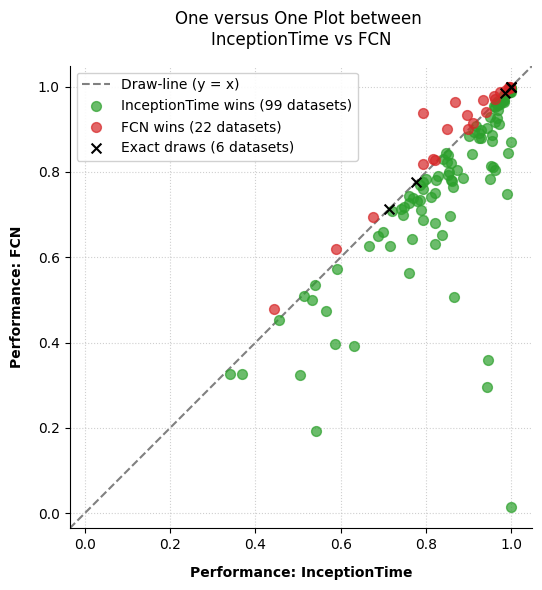

In [4]:
# Generate the 1vs1 plot
fig_ab = plot_one_vs_one(
  data=eval_data,
  model_x='InceptionTime',
  model_y='FCN',
)

**How to interpret this plot:**

* **The Diagonal Line:** Represents absolute equality ($X = Y$).
* **The Region Below the Line:** Because `higher_is_better=True`, points here mean $X > Y$, so the model on the X-axis (`InceptionTime`) won on those specific datasets.
* **The Distance from the Line:** The further a point is from the diagonal, the larger the margin of victory. A point just barely below the line is a narrow win; a point far away is a crushing victory.